# Mission 1 — Données et analyse exploratoire (EDA)

## Prédiction du Churn Client

Cette mission consiste à explorer le jeu de données **Telco Customer Churn**
afin de comprendre sa structure, la qualité des données et les caractéristiques
des clients avant la phase de préparation et de modélisation.

L'objectif est notamment d'identifier les valeurs manquantes, les doublons,
les éventuelles anomalies et les variables pouvant être associées au départ
des clients.

## 1. Importation des bibliothèques

Nous importons les bibliothèques nécessaires à l'analyse exploratoire :

- **NumPy** pour les opérations numériques ;
- **Pandas** pour la manipulation des données ;
- **Matplotlib** et **Seaborn** pour les visualisations ;
- **Scikit-learn** pour le calcul de l'information mutuelle.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_classif

print("Imports OK")

Imports OK


## 2. Chargement du jeu de données

Le jeu de données utilisé est **Telco Customer Churn**. Il contient des
informations sur les clients d'un opérateur télécom ainsi que la variable
cible `Churn`, qui indique si un client a résilié son abonnement.

Nous chargeons le fichier CSV avec Pandas.

In [3]:
DATA_PATH = "../data/raw/Telco-Customer-Churn.csv"

df = pd.read_csv(DATA_PATH)

### Aperçu des données

Nous affichons les cinq premières lignes du dataset afin d'observer sa
structure et d'avoir un premier aperçu des variables disponibles.

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Profiling des données

### 3.1. Dimensions du dataset

Nous déterminons le nombre de lignes et de colonnes du dataset.

Le nombre de lignes correspond au nombre d'observations, c'est-à-dire aux
clients, tandis que le nombre de colonnes correspond aux différentes variables
disponibles.

In [5]:
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

Nombre de lignes : 7043
Nombre de colonnes : 21


### Observation

Le dataset contient **7 043 clients** décrits par **21 variables**.

Chaque ligne représente un client de l'opérateur télécom. Parmi les colonnes,
`Churn` constitue la variable cible que nous chercherons à prédire dans les
prochaines étapes du projet.

### 3.2. Informations générales

La méthode `info()` permet d'obtenir une vue générale du dataset :
le nombre d'observations, les colonnes, leurs types et le nombre de valeurs
non nulles.

Cette analyse permet notamment de repérer les variables dont le type pourrait
être incorrect.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### 3.3. Types des variables

Nous examinons le type de chaque variable afin de distinguer les variables
numériques des variables catégorielles.

Cette vérification permet également de détecter une variable numérique qui
aurait été interprétée comme du texte.

In [7]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

### Observation

Le dataset contient initialement :

- **2 variables numériques entières** : `SeniorCitizen` et `tenure` ;
- **1 variable numérique continue** : `MonthlyCharges` ;
- **18 variables de type texte**, dont la cible `Churn`.

La variable `TotalCharges` est interprétée comme une variable textuelle (`str`)
alors qu'elle représente un montant. Cette anomalie de typage nécessite une
analyse particulière.

### 3.4. Variables numériques et catégorielles

Nous séparons les colonnes selon leur type afin de mieux comprendre la
composition du dataset.

Cette distinction sera utile pour les analyses statistiques et graphiques
réalisées dans la suite de l'EDA.

In [8]:
numeric_cols = df.select_dtypes(include='number').columns
categorical_cols = df.select_dtypes(exclude='number').columns

print("Variables numériques :")
print(numeric_cols)

print("\nVariables catégorielles :")
print(categorical_cols)

Variables numériques :
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='str')

Variables catégorielles :
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='str')


### Observation

La détection automatique identifie trois colonnes numériques :
`SeniorCitizen`, `tenure` et `MonthlyCharges`.

`TotalCharges` apparaît parmi les variables catégorielles en raison de son type
`str`. Cependant, cette variable correspond conceptuellement à une valeur
numérique et devra être convertie avant son utilisation dans les analyses
numériques et la modélisation.

La variable `customerID` est un identifiant unique et non une caractéristique
métier du client.

### 3.5. Recherche des valeurs manquantes

Nous recherchons les valeurs manquantes dans chaque colonne et calculons leur
pourcentage par rapport au nombre total d'observations.

Cette étape permet d'identifier les variables nécessitant un traitement
particulier lors de la préparation des données.

In [9]:
missing = pd.DataFrame({
    "Nombre": df.isna().sum(),
    "Pourcentage (%)": df.isna().mean() * 100
})

missing.sort_values(
    "Pourcentage (%)",
    ascending=False
)

,Nombre,Pourcentage (%)
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


### Observation

L'utilisation de `isna()` ne détecte aucune valeur manquante dans les
21 colonnes du dataset.

Cependant, cette première vérification n'est pas suffisante. Certaines valeurs
manquantes peuvent être représentées par des chaînes vides ou des espaces,
notamment dans une colonne textuelle telle que `TotalCharges`.

Une vérification spécifique de cette variable est donc nécessaire.

### 3.6. Vérification de la variable `TotalCharges`

Le cahier des charges attire particulièrement l'attention sur la variable
`TotalCharges`.

Bien qu'elle représente un montant, cette variable peut être interprétée
comme une variable textuelle en raison de la présence de certaines valeurs
non numériques.

Nous essayons donc de la convertir en variable numérique. Les valeurs qui
ne peuvent pas être converties seront représentées par `NaN` afin de pouvoir
les identifier.

In [10]:
total_charges_num = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print(
    "Nombre de valeurs non convertibles ou manquantes :",
    total_charges_num.isna().sum()
)

Nombre de valeurs non convertibles ou manquantes : 11


### 3.7. Identification des valeurs problématiques de `TotalCharges`

Nous affichons les observations pour lesquelles `TotalCharges` n'a pas pu
être convertie en valeur numérique.

Cette vérification permet de comprendre l'origine du problème avant de décider
du traitement à appliquer dans la phase de préparation.

In [11]:
df.loc[
    total_charges_num.isna(),
    ["customerID", "tenure", "TotalCharges", "Churn"]
]

,customerID,tenure,TotalCharges,Churn
488,4472-LVYGI,0,,No
753,3115-CZMZD,0,,No
936,5709-LVOEQ,0,,No
1082,4367-NUYAO,0,,No
1340,1371-DWPAZ,0,,No
3331,7644-OMVMY,0,,No
3826,3213-VVOLG,0,,No
4380,2520-SGTTA,0,,No
5218,2923-ARZLG,0,,No
6670,4075-WKNIU,0,,No


### Observation

La conversion de `TotalCharges` en valeur numérique révèle **11 observations
non convertibles**.

L'analyse de ces observations montre qu'elles correspondent toutes à des clients
ayant une ancienneté (`tenure`) égale à **0**. Leur valeur `TotalCharges` est
vide, ce qui explique pourquoi la colonne était initialement interprétée comme
du texte.

Ces 11 observations représentent une très faible proportion du dataset.
Aucune imputation n'est réalisée pendant cette analyse exploratoire. Le
traitement définitif de ces valeurs sera effectué dans le pipeline de
préparation de la Mission 2, après la séparation des données d'entraînement
et de test.

### 3.8. Recherche des doublons

Nous vérifions si certaines lignes du dataset sont présentes plusieurs fois.

La présence de doublons pourrait donner un poids excessif à certaines
observations et influencer les analyses ainsi que les futurs modèles.

In [12]:
print(
    "Nombre de lignes dupliquées :",
    df.duplicated().sum()
)

Nombre de lignes dupliquées : 0


### Observation

Aucune ligne entièrement dupliquée n'a été détectée dans le dataset.

Nous pouvons donc poursuivre l'analyse sans avoir à supprimer de doublons
à ce stade.

### 3.9. Vérification de l'identifiant client

La variable `customerID` représente l'identifiant unique de chaque client.
Nous vérifions donc qu'un même identifiant n'apparaît pas plusieurs fois dans
le dataset.
    

In [13]:
print(
    "Nombre de customerID dupliqués :",
    df["customerID"].duplicated().sum()
)

print(
    "Nombre de clients uniques :",
    df["customerID"].nunique()
)

Nombre de customerID dupliqués : 0
Nombre de clients uniques : 7043


### Observation

Les **7 043 clients possèdent tous un `customerID` unique** et aucun identifiant
dupliqué n'a été détecté.

Cette variable joue donc correctement son rôle d'identifiant. Cependant,
`customerID` ne représente pas une caractéristique comportementale ou
contractuelle du client et ne sera pas utilisé comme variable prédictive.

### 3.10. Statistiques descriptives des variables numériques

Nous calculons les principales statistiques descriptives des variables
numériques : moyenne, écart-type, minimum, maximum et quartiles.

Ces informations permettent d'obtenir une première compréhension de la
distribution des variables et de repérer d'éventuelles valeurs inhabituelles.

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


### Observation

L'ancienneté (`tenure`) varie de **0 à 72 mois**, avec une moyenne d'environ
**32,37 mois** et une médiane de **29 mois**.

Les charges mensuelles (`MonthlyCharges`) varient de **18,25 à 118,75**, avec
une moyenne d'environ **64,76** et une médiane de **70,35**.

La variable `SeniorCitizen` est binaire : `0` indique que le client n'est pas
senior et `1` qu'il l'est. Sa moyenne d'environ **0,162** indique qu'environ
16,2 % des clients sont identifiés comme seniors.

Ces statistiques donnent une première description du profil des clients,
mais elles ne permettent pas encore de déterminer quelles variables sont
associées au churn.

### 3.11. Recherche des variables quasi-constantes

Une variable quasi-constante est une variable pour laquelle une même valeur
est présente dans une très grande majorité des observations.

Ces variables peuvent apporter peu d'information pour distinguer les clients.
Nous calculons donc, pour chaque variable, la proportion de la modalité la
plus fréquente.

Dans cette analyse, nous considérons comme quasi-constante une variable dont
la modalité dominante représente au moins **95 %** des observations.

In [15]:
quasi_constant = []

for col in df.columns:
    proportion = df[col].value_counts(
        normalize=True,
        dropna=False
    ).iloc[0]

    if proportion >= 0.95:
        quasi_constant.append({
            "Variable": col,
            "Proportion dominante (%)": round(proportion * 100, 2)
        })

if quasi_constant:
    display(pd.DataFrame(quasi_constant))
else:
    print("Aucune variable quasi-constante détectée avec le seuil de 95 %.")

Aucune variable quasi-constante détectée avec le seuil de 95 %.


### Observation

Aucune variable quasi-constante n'a été détectée avec le seuil fixé à **95 %**.

Cela signifie qu'aucune variable ne possède une même valeur dans au moins
95 % des observations. À ce stade, aucune variable ne doit donc être écartée
pour cause de quasi-constance.

### 3.12. Préparation de `TotalCharges` pour l'analyse

La variable `TotalCharges` représente un montant mais est actuellement stockée
sous forme de texte.

Pour les besoins de l'analyse exploratoire, nous créons une version numérique
de cette variable. Les 11 valeurs non convertibles identifiées précédemment
seront représentées par `NaN`.

Cette conversion est réalisée uniquement pour l'EDA. Aucune imputation n'est
effectuée à ce stade.

In [16]:
df["TotalCharges_num"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
#Vérification :

df[[
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges_num"
]].dtypes

SeniorCitizen         int64
tenure                int64
MonthlyCharges      float64
TotalCharges_num    float64
dtype: object

### 3.13. Analyse des corrélations

Nous étudions les corrélations entre les variables numériques afin de détecter
d'éventuelles relations fortes entre elles.

Une forte corrélation peut indiquer que deux variables contiennent des
informations similaires ou liées.

Nous utilisons ici le coefficient de corrélation de Pearson, dont la valeur
est comprise entre -1 et 1. Plus la valeur absolue est proche de 1, plus la
relation linéaire entre les deux variables est forte.

In [17]:
numeric_eda = df[[
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges_num"
]]

corr_matrix = numeric_eda.corr()

corr_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges_num
SeniorCitizen,1.000000,0.016567,0.220173,0.102411
tenure,0.016567,1.000000,0.247900,0.825880
MonthlyCharges,0.220173,0.247900,1.000000,0.651065
TotalCharges_num,0.102411,0.825880,0.651065,1.000000


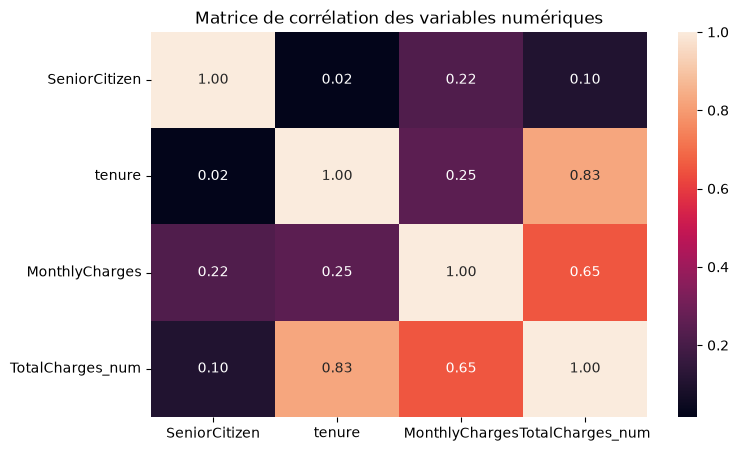

In [18]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Matrice de corrélation des variables numériques")
plt.show()

### Observation

La matrice de corrélation met en évidence une **forte corrélation positive**
entre `tenure` et `TotalCharges_num`, avec un coefficient d'environ **0,83**.
Cela est cohérent puisque les charges totales accumulées augmentent généralement
avec l'ancienneté du client.

Une corrélation positive relativement importante (**0,65**) est également
observée entre `MonthlyCharges` et `TotalCharges_num`.

En revanche, les autres relations sont faibles : `tenure` et
`MonthlyCharges` présentent une corrélation d'environ **0,25**, tandis que
`SeniorCitizen` est faiblement corrélée aux autres variables numériques.

Ainsi, `tenure` et `TotalCharges_num` constituent la paire de variables
numériques la plus fortement corrélée du dataset. Cette relation devra être
prise en compte lors de la suite de l'analyse, mais elle ne justifie pas à
elle seule la suppression d'une des deux variables.

## 4. Détection de fuite de données

Une fuite de données (*data leakage*) se produit lorsqu'une variable utilisée
pour prédire la cible contient une information qui ne serait pas disponible
au moment réel de la prédiction.

Dans notre cas, le modèle doit prédire le risque de départ d'un client avant
sa résiliation. Une variable connue uniquement après le départ du client
pourrait donc fausser l'évaluation du modèle et produire des performances
artificiellement élevées.

Nous allons examiner les variables du dataset et leur relation avec `Churn`
afin d'identifier d'éventuelles variables suspectes.

### 4.1. Analyse des variables disponibles

Nous commençons par examiner la liste des variables afin de déterminer
leur signification métier et de rechercher une éventuelle information qui
serait connue uniquement après la résiliation du client.

In [19]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'TotalCharges_num']

### 4.2. Nombre de valeurs uniques par variable

Nous examinons le nombre de valeurs uniques de chaque variable.

Cette vérification permet notamment d'identifier les variables de type
identifiant et de mieux comprendre la structure des variables catégorielles.

Une variable possédant une valeur presque unique pour chaque observation
n'est pas nécessairement une fuite de données, mais elle doit être examinée
avant d'être utilisée comme variable prédictive.

In [20]:
unique_values = pd.DataFrame({
    "Variable": df.columns,
    "Valeurs_uniques": [df[col].nunique() for col in df.columns]
})

unique_values.sort_values(
    "Valeurs_uniques",
    ascending=False
)

,Variable,Valeurs_uniques
0,customerID,7043
19,TotalCharges,6531
21,TotalCharges_num,6530
18,MonthlyCharges,1585
5,tenure,73
17,PaymentMethod,4
14,StreamingMovies,3
13,StreamingTV,3
11,DeviceProtection,3
12,TechSupport,3


### Observation sur les valeurs uniques

La variable `customerID` possède **7 043 valeurs uniques**, soit une valeur
différente pour chaque client. Elle correspond donc à un identifiant et non
à une caractéristique métier du client.

`TotalCharges` possède également un grand nombre de valeurs distinctes, ce
qui est cohérent avec une variable représentant un montant.

Les autres variables catégorielles possèdent entre 2 et 4 modalités, tandis
que `tenure` possède 73 valeurs différentes.

`customerID` ne sera pas utilisée comme variable prédictive, car son caractère
unique ne fournit pas une information généralisable sur le comportement des
clients.

### 4.3. Relation entre les variables catégorielles et `Churn`

Nous calculons le taux de churn pour les modalités des variables
catégorielles afin de rechercher une éventuelle relation anormalement forte
avec la cible.

Une variable permettant de déterminer presque parfaitement `Churn` devra
être examinée attentivement afin de vérifier qu'elle ne contient pas une
information disponible uniquement après la résiliation.

In [21]:
categorical_features = [
    col for col in categorical_cols
    if col not in ["customerID", "Churn", "TotalCharges"]
]

for col in categorical_features:

    table = pd.crosstab(
        df[col],
        df["Churn"],
        normalize="index"
    ) * 100

    print(f"\n--- {col} ---")
    print(table.round(2))


--- gender ---
Churn      No    Yes
gender              
Female  73.08  26.92
Male    73.84  26.16

--- Partner ---
Churn       No    Yes
Partner              
No       67.04  32.96
Yes      80.34  19.66

--- Dependents ---
Churn          No    Yes
Dependents              
No          68.72  31.28
Yes         84.55  15.45

--- PhoneService ---
Churn            No    Yes
PhoneService              
No            75.07  24.93
Yes           73.29  26.71

--- MultipleLines ---
Churn                No    Yes
MultipleLines                 
No                74.96  25.04
No phone service  75.07  24.93
Yes               71.39  28.61

--- InternetService ---
Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40

--- OnlineSecurity ---
Churn                   No    Yes
OnlineSecurity                   
No                   58.23  41.77
No internet service  92.60   7.40
Yes                  85.39  14.6

### Observation sur la relation avec `Churn`

L'analyse des variables catégorielles ne met en évidence aucune modalité
permettant de prédire presque parfaitement la variable `Churn`.

Certaines variables présentent néanmoins des différences importantes de taux
de churn. Par exemple :

- les clients avec un contrat `Month-to-month` ont un taux de churn de **42,71 %**,
  contre seulement **2,83 %** pour les contrats de deux ans ;
- les clients utilisant `Electronic check` atteignent **45,29 %** de churn ;
- les clients utilisant la fibre optique (`Fiber optic`) présentent **41,89 %**
  de churn ;
- les clients sans `OnlineSecurity` présentent **41,77 %** de churn.

Ces relations montrent que certaines caractéristiques sont associées au churn,
mais aucune ne détermine la cible de manière quasi parfaite.

Une forte association avec `Churn` ne constitue pas à elle seule une fuite
de données. Il faut également vérifier si la variable serait disponible au
moment où la prédiction est réalisée.

### 4.4. Vérification de la disponibilité des variables au moment de la prédiction

La détection d'une fuite de données nécessite également une analyse métier.
Une variable serait considérée comme une fuite si sa valeur n'était connue
qu'après la résiliation du client.

Les variables du dataset décrivent principalement :

- le profil du client (`gender`, `SeniorCitizen`, `Partner`, `Dependents`) ;
- son ancienneté (`tenure`) ;
- les services souscrits (`InternetService`, `OnlineSecurity`,
  `TechSupport`, etc.) ;
- son contrat et son mode de facturation (`Contract`,
  `PaperlessBilling`, `PaymentMethod`) ;
- ses charges (`MonthlyCharges`, `TotalCharges`).

Ces informations peuvent être disponibles pendant que le client est encore
abonné et peuvent donc, dans le cadre de ce projet, être utilisées pour
prédire son risque de départ.

La variable `Churn` est la cible et ne doit évidemment jamais être utilisée
comme variable d'entrée du modèle.

`customerID` sera également exclue des variables prédictives, car il s'agit
uniquement d'un identifiant unique du client.

### Conclusion — Détection de fuite de données

Les vérifications effectuées n'ont pas mis en évidence de variable prédisant
`Churn` de manière anormalement parfaite.

L'analyse métier des variables ne révèle pas non plus, dans le cadre du dataset
fourni, de caractéristique explicitement connue uniquement après la résiliation.

Nous considérons donc qu'**aucune fuite de données évidente n'a été détectée
parmi les variables explicatives disponibles**.

La variable cible `Churn` sera exclue des entrées du modèle et `customerID`
sera également retirée, car elle constitue uniquement un identifiant.

Cette conclusion reste liée à l'interprétation des variables fournie par le
dataset : dans un système réel, il faudrait confirmer avec l'opérateur que
chaque information est effectivement disponible avant la résiliation.

In [22]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'TotalCharges_num'],
      dtype='str')

In [23]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
TotalCharges_num    float64
dtype: object

## 5. Analyse bivariée

L'analyse bivariée consiste à étudier la relation entre chaque variable
explicative et la variable cible `Churn`.

Pour les variables catégorielles, nous comparerons le taux de churn entre
les différentes modalités.

Pour les variables numériques, nous comparerons leur distribution entre
les clients ayant résilié (`Yes`) et ceux n'ayant pas résilié (`No`).

L'objectif est d'identifier les caractéristiques qui semblent les plus
associées au départ des clients.

### 5.1. Création d'une représentation numérique de `Churn`

Pour faciliter les calculs du taux de churn, nous créons une représentation
numérique de la variable cible :

- `No` = 0 : le client n'a pas résilié ;
- `Yes` = 1 : le client a résilié.

Cette nouvelle variable est créée uniquement pour faciliter l'analyse
exploratoire. La variable originale `Churn` est conservée.

In [24]:
df["Churn_num"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

df[["Churn", "Churn_num"]].head()

,Churn,Churn_num
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


### 5.2. Taux global de churn

Avant d'analyser chaque variable, nous calculons le taux global de churn
dans le dataset.

Cette valeur servira de référence pour comparer les taux observés dans les
différentes catégories de clients.

In [25]:
churn_global = df["Churn_num"].mean() * 100

print(f"Taux global de churn : {churn_global:.2f} %")

Taux global de churn : 26.54 %


### 5.3. Taux de churn selon les variables catégorielles

Pour chaque variable catégorielle, nous calculons le taux de churn associé
à chacune de ses modalités.

Cette analyse permet d'identifier les catégories de clients dont le taux
de résiliation est supérieur ou inférieur au taux global observé.

La variable `customerID` est exclue de cette analyse, car elle constitue
un identifiant unique et non une caractéristique métier du client.

`TotalCharges` est également exclue des variables catégorielles, car elle
représente conceptuellement une variable numérique.

In [26]:
def churn_rate_by_category(data, column):
    result = (
        data.groupby(column)["Churn_num"]
        .agg(["count", "mean"])
        .rename(columns={
            "count": "Nombre_clients",
            "mean": "Taux_churn"
        })
    )

    result["Taux_churn"] = (
        result["Taux_churn"] * 100
    ).round(2)

    return result.sort_values(
        "Taux_churn",
        ascending=False
    )

### 5.4. Taux de churn selon le type de contrat

Nous étudions la relation entre le type de contrat (`Contract`) et le churn.

L'objectif est de déterminer si la durée d'engagement du client semble être
associée à sa probabilité de résiliation.

In [27]:
churn_rate_by_category(df, "Contract")

,Nombre_clients,Taux_churn
Contract,,
Month-to-month,3875,42.71
One year,1473,11.27
Two year,1695,2.83


Nous représentons ensuite ces taux graphiquement afin de faciliter la
comparaison entre les différents types de contrat.

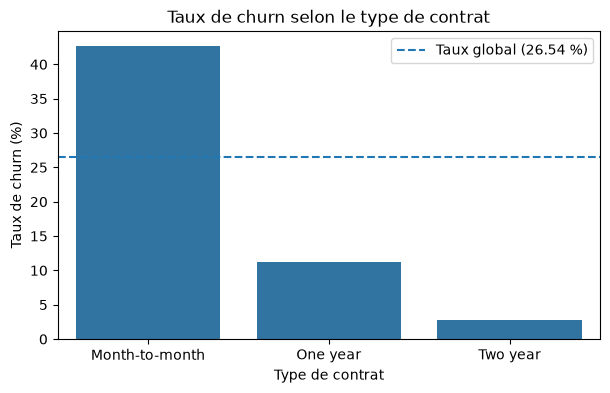

In [28]:
contract_churn = (
    df.groupby("Contract")["Churn_num"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 4))

sns.barplot(
    x=contract_churn.index,
    y=contract_churn.values
)

plt.axhline(
    churn_global,
    linestyle="--",
    label=f"Taux global ({churn_global:.2f} %)"
)

plt.title("Taux de churn selon le type de contrat")
plt.xlabel("Type de contrat")
plt.ylabel("Taux de churn (%)")
plt.legend()

plt.show()

### Observation

Le taux global de churn dans le dataset est de **26,54 %**.

Le type de contrat semble fortement associé au départ des clients :

- les clients avec un contrat **Month-to-month** présentent un taux de churn
  de **42,71 %**, largement supérieur au taux global ;
- les clients avec un contrat de **One year** ont un taux de churn de
  **11,27 %** ;
- les clients avec un contrat de **Two year** présentent seulement
  **2,83 %** de churn.

Ces résultats montrent que le taux de churn diminue fortement lorsque la durée
d'engagement augmente. Les clients avec un contrat mensuel semblent donc
beaucoup plus exposés au risque de résiliation que les clients engagés sur
un ou deux ans.

La variable `Contract` apparaît ainsi comme une variable potentiellement
importante pour expliquer le churn.

### 5.5. Analyse des autres variables catégorielles

Après l'analyse détaillée de `Contract`, nous appliquons le même calcul aux
autres variables catégorielles.

Pour chaque modalité, nous affichons le nombre de clients ainsi que le taux
de churn correspondant.

In [29]:
categorical_features = [
    col for col in df.select_dtypes(include="str").columns
    if col not in ["customerID", "Churn", "TotalCharges"]
]

for col in categorical_features:
    print(f"\n===== {col} =====")
    display(churn_rate_by_category(df, col))


===== gender =====


,Nombre_clients,Taux_churn
gender,,
Female,3488,26.92
Male,3555,26.16



===== Partner =====


,Nombre_clients,Taux_churn
Partner,,
No,3641,32.96
Yes,3402,19.66



===== Dependents =====


...

,Nombre_clients,Taux_churn
Contract,,
Month-to-month,3875,42.71
One year,1473,11.27
Two year,1695,2.83



===== PaperlessBilling =====


,Nombre_clients,Taux_churn
PaperlessBilling,,
Yes,4171,33.57
No,2872,16.33



===== PaymentMethod =====


,Nombre_clients,Taux_churn
PaymentMethod,,
Electronic check,2365,45.29
Mailed check,1612,19.11
Bank transfer (automatic),1544,16.71
Credit card (automatic),1522,15.24


### Observation sur les variables catégorielles

L'analyse met en évidence des différences importantes de taux de churn selon
certaines caractéristiques des clients. Le taux global de churn étant de
**26,54 %**, plusieurs modalités se distinguent nettement.

Le **type de contrat** présente une forte association avec le churn. Les clients
en contrat `Month-to-month` ont un taux de churn de **42,71 %**, contre
**11,27 %** pour `One year` et seulement **2,83 %** pour `Two year`.

Le **mode de paiement** montre également des différences importantes. Les clients
utilisant `Electronic check` présentent le taux de churn le plus élevé,
avec **45,29 %**, alors que les autres modes de paiement se situent entre
**15,24 % et 19,11 %**.

Le **service Internet** semble aussi associé au churn. Les clients utilisant
la fibre optique (`Fiber optic`) présentent **41,89 %** de churn, contre
**18,96 %** pour DSL et **7,40 %** pour les clients sans service Internet.

L'absence de certains services est également associée à un taux de churn élevé,
notamment `OnlineSecurity` (**41,77 %**), `TechSupport` (**41,64 %**),
`OnlineBackup` (**39,93 %**) et `DeviceProtection` (**39,13 %**).

Les clients sans partenaire (**32,96 %**) ou sans personnes à charge
(**31,28 %**) présentent également davantage de churn que ceux ayant un
partenaire (**19,66 %**) ou des personnes à charge (**15,45 %**).

Enfin, certaines variables présentent peu de différence entre leurs modalités.
C'est notamment le cas de `gender`, `PhoneService` et, dans une moindre mesure,
`MultipleLines`.

Ces résultats indiquent donc que certaines variables catégorielles, notamment
`Contract`, `PaymentMethod`, `InternetService`, `OnlineSecurity` et
`TechSupport`, semblent particulièrement associées au churn. Leur pouvoir
discriminant sera évalué plus précisément avec l'information mutuelle.

### 5.6. Analyse des variables numériques

Pour les variables numériques, nous comparons leur distribution entre les
clients ayant résilié (`Churn = Yes`) et ceux qui sont restés (`Churn = No`).

Nous étudions principalement `tenure`, `MonthlyCharges` et `TotalCharges_num`.

La variable `SeniorCitizen`, bien que stockée sous forme numérique (`0` ou `1`),
représente une caractéristique binaire. Elle sera donc analysée séparément
comme une variable à deux modalités.

In [30]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges_num"
]

df.groupby("Churn")[numeric_features].describe().round(2)

tenure                                            MonthlyCharges  \
        count   mean    std  min   25%   50%   75%   max          count   
Churn                                                                     
No     5174.0  37.57  24.11  0.0  15.0  38.0  61.0  72.0         5174.0   
Yes    1869.0  17.98  19.53  1.0   2.0  10.0  29.0  72.0         1869.0   

              ...               TotalCharges_num                           \
        mean  ...   75%     max            count     mean      std    min   
Churn         ...                                                           
No     61.27  ...  88.4  118.75           5163.0  2555.34  2329.46  18.80   
Yes    74.44  ...  94.2  118.35           1869.0  1531.80  1890.82  18.85   

                                          
          25%      50%      75%      max  
Churn                                     
No     577.83  1683.60  4264.12  8672.45  
Yes    134.50   703.55  2331.30  8684.80  

[2 rows x 24 columns]

### Observation sur les variables numériques

La comparaison des variables numériques selon `Churn` met en évidence plusieurs
différences entre les clients ayant résilié et ceux qui sont restés.

#### Ancienneté (`tenure`)

L'ancienneté semble fortement associée au churn. Les clients ayant résilié ont
une ancienneté moyenne de **17,98 mois**, contre **37,57 mois** pour les clients
n'ayant pas résilié.

La différence est également visible au niveau de la médiane : **10 mois** pour
les clients ayant churné contre **38 mois** pour les autres.

Les clients ayant une faible ancienneté semblent donc davantage représentés
parmi les clients ayant résilié.

#### Charges mensuelles (`MonthlyCharges`)

Les clients ayant résilié présentent des charges mensuelles moyennes plus
élevées, avec **74,44**, contre **61,27** pour les clients n'ayant pas résilié.

Cette différence suggère une association entre des charges mensuelles plus
élevées et le churn.

#### Charges totales (`TotalCharges_num`)

Les clients ayant résilié présentent des charges totales moyennes plus faibles :
**1 531,80**, contre **2 555,34** pour les clients n'ayant pas résilié.

La médiane montre également une différence importante : **703,55** chez les
clients ayant churné contre **1 683,60** chez les autres.

Cette différence peut notamment être liée à l'ancienneté plus faible des clients
ayant résilié, puisque `TotalCharges_num` est fortement corrélée à `tenure`.

Ces résultats montrent que `tenure`, `MonthlyCharges` et `TotalCharges_num`
présentent des distributions différentes selon le statut de churn. Des
visualisations permettront de mieux observer ces différences.

### 5.7. Distribution de l'ancienneté selon le churn

Nous visualisons la distribution de `tenure` selon la variable cible afin de
comparer l'ancienneté des clients ayant résilié avec celle des clients étant
restés.

Un boxplot permet de comparer notamment la médiane, les quartiles et la
dispersion de l'ancienneté dans les deux groupes.

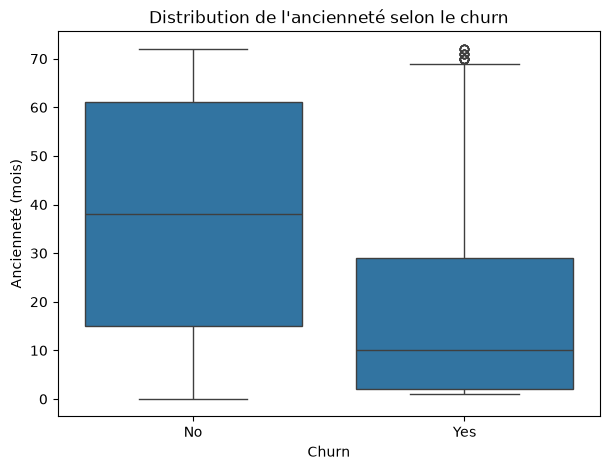

In [31]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Distribution de l'ancienneté selon le churn")
plt.xlabel("Churn")
plt.ylabel("Ancienneté (mois)")

plt.show()

### Observation

Le boxplot montre une différence importante d'ancienneté entre les clients
ayant résilié et ceux qui sont restés.

Pour les clients n'ayant pas churné (`No`), la médiane de `tenure` est de
**38 mois**, alors qu'elle est seulement de **10 mois** pour les clients ayant
churné (`Yes`).

La majorité des clients ayant résilié se concentre donc vers des anciennetés
plus faibles. À l'inverse, les clients n'ayant pas résilié présentent
globalement une ancienneté plus élevée.

Quelques clients ayant churné possèdent néanmoins une ancienneté élevée,
visible par les valeurs situées autour de 70 mois.

Cette analyse suggère que `tenure` est une variable importante pour distinguer
les clients selon leur comportement de churn.

### 5.8. Distribution des charges mensuelles selon le churn

Nous comparons maintenant les charges mensuelles (`MonthlyCharges`) des clients
ayant résilié avec celles des clients étant restés.

L'objectif est de déterminer si le niveau des charges mensuelles diffère selon
le statut de churn.

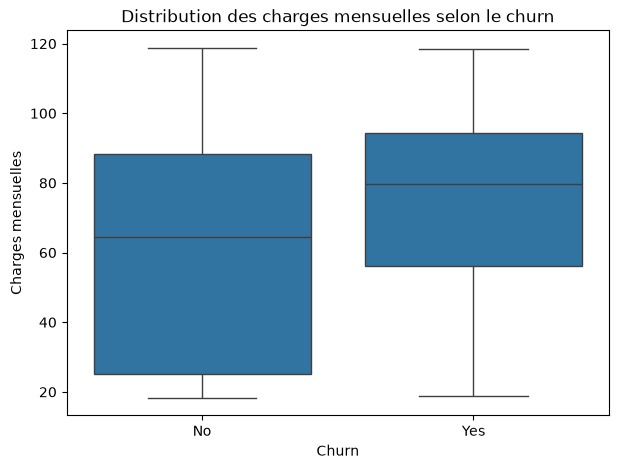

In [32]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Distribution des charges mensuelles selon le churn")
plt.xlabel("Churn")
plt.ylabel("Charges mensuelles")

plt.show()

### Observation

Le boxplot montre que les clients ayant résilié (`Yes`) présentent globalement
des charges mensuelles plus élevées que les clients n'ayant pas résilié (`No`).

La médiane des charges mensuelles est plus élevée chez les clients ayant churné.
Cette tendance est également confirmée par les statistiques descriptives :
la moyenne est de **74,44** pour les clients ayant churné, contre **61,27**
pour ceux n'ayant pas churné.

Les deux distributions se chevauchent néanmoins fortement. Des clients avec
des charges mensuelles élevées sont présents dans les deux groupes.

Ainsi, `MonthlyCharges` semble être associée au churn, mais cette variable
ne permet pas à elle seule de distinguer parfaitement les clients qui
résilient de ceux qui restent.

### 5.9. Distribution des charges totales selon le churn

Nous comparons les charges totales accumulées (`TotalCharges_num`) entre les
clients ayant résilié et ceux qui sont restés.

Cette variable doit être interprétée avec prudence, car nous avons précédemment
observé une forte corrélation entre `TotalCharges_num` et l'ancienneté
(`tenure`).

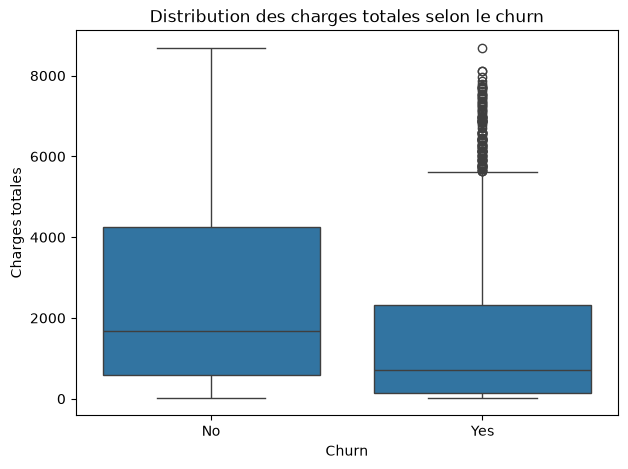

In [33]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges_num"
)

plt.title("Distribution des charges totales selon le churn")
plt.xlabel("Churn")
plt.ylabel("Charges totales")

plt.show()

### Observation

Le boxplot montre que les clients ayant résilié (`Yes`) présentent globalement
des charges totales plus faibles que les clients n'ayant pas résilié (`No`).

La médiane de `TotalCharges_num` est de **703,55** pour les clients ayant churné,
contre **1 683,60** pour ceux n'ayant pas churné. Les moyennes suivent également
cette tendance, avec **1 531,80** contre **2 555,34**.

On observe cependant plusieurs valeurs élevées chez les clients ayant churné,
ce qui montre que certains clients ayant accumulé des charges importantes ont
également résilié.

Cette différence doit être interprétée avec prudence, car `TotalCharges_num`
est fortement corrélée à `tenure` (**0,83**). Les clients ayant churné ayant
généralement une ancienneté plus faible, ils ont également eu moins de temps
pour accumuler des charges totales élevées.

Ainsi, `TotalCharges_num` est associée au churn, mais cette relation est
également liée à l'ancienneté du client.

### 5.10. Taux de churn selon le statut SeniorCitizen

La variable `SeniorCitizen` est stockée sous forme numérique, mais représente
une caractéristique binaire :

- `0` : client non senior ;
- `1` : client senior.

Nous comparons donc le taux de churn entre ces deux groupes plutôt que
d'analyser cette variable comme une variable numérique continue.

In [34]:
churn_rate_by_category(df, "SeniorCitizen")

,Nombre_clients,Taux_churn
SeniorCitizen,,
1,1142,41.68
0,5901,23.61


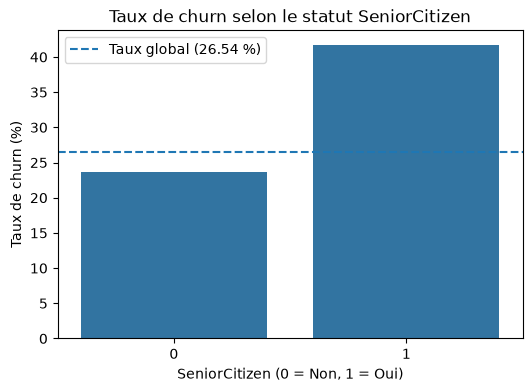

In [35]:
senior_churn = (
    df.groupby("SeniorCitizen")["Churn_num"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(6, 4))

sns.barplot(
    x=senior_churn.index,
    y=senior_churn.values
)

plt.axhline(
    churn_global,
    linestyle="--",
    label=f"Taux global ({churn_global:.2f} %)"
)

plt.title("Taux de churn selon le statut SeniorCitizen")
plt.xlabel("SeniorCitizen (0 = Non, 1 = Oui)")
plt.ylabel("Taux de churn (%)")
plt.legend()

plt.show()

### Observation

Le taux de churn varie fortement selon le statut `SeniorCitizen`.

Les clients seniors (`SeniorCitizen = 1`) présentent un taux de churn de
**41,68 %**, nettement supérieur au taux global de **26,54 %**.

À l'inverse, les clients non seniors (`SeniorCitizen = 0`) présentent un taux
de churn de **23,61 %**, inférieur au taux global.

Cette différence suggère que le statut `SeniorCitizen` est associé au churn
et peut apporter une information utile pour distinguer les clients présentant
un risque de résiliation plus élevé.

Cette observation met en évidence une association statistique et ne permet
pas, à elle seule, de conclure que le statut senior est la cause du churn.

### 5.11. Classement des variables par information mutuelle

Après l'analyse individuelle des variables, nous cherchons à quantifier leur
pouvoir discriminant vis-à-vis de la variable cible `Churn`.

Pour cela, nous utilisons l'**information mutuelle** (*Mutual Information*).

L'information mutuelle mesure le niveau de dépendance entre une variable
explicative et la cible :

- une valeur proche de **0** indique que la variable apporte peu d'information
  sur la cible ;
- une valeur plus élevée indique une dépendance plus importante avec `Churn`.

Cette méthode peut détecter des relations qui ne sont pas nécessairement
linéaires.

L'objectif est ici de classer les variables et d'identifier les **5 features
les plus discriminantes**.

### 5.12. Préparation des variables

Le calcul de l'information mutuelle nécessite des données numériques.

Nous créons donc une copie des variables explicatives afin de réaliser un
encodage destiné uniquement à cette analyse exploratoire.

`customerID` est exclue car il s'agit d'un identifiant unique.

La version textuelle de `TotalCharges` est également exclue au profit de
`TotalCharges_num`.

Enfin, `Churn` et `Churn_num` sont exclues des variables explicatives puisqu'elles
représentent la cible.

In [36]:
X_mi = df.drop(
    columns=[
        "customerID",
        "Churn",
        "Churn_num",
        "TotalCharges"
    ]
).copy()

y_mi = df["Churn_num"]

X_mi.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges_num
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [37]:
print("Nombre de features :", X_mi.shape[1])
print(X_mi.columns.tolist())

Nombre de features : 19
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges_num']


### 5.13. Traitement temporaire des valeurs manquantes

`TotalCharges_num` contient les 11 valeurs manquantes identifiées lors du
profiling.

Pour permettre le calcul de l'information mutuelle, ces valeurs sont remplacées
temporairement par la médiane de `TotalCharges_num`.

Cette opération est réalisée uniquement pour l'EDA et ne constitue pas le
pipeline de préparation du futur modèle.

In [38]:
X_mi["TotalCharges_num"] = X_mi["TotalCharges_num"].fillna(
    X_mi["TotalCharges_num"].median()
)

X_mi.isna().sum().sum()

np.int64(0)

### 5.14. Encodage temporaire des variables catégorielles

Les variables catégorielles sont actuellement représentées sous forme de texte.

Pour calculer l'information mutuelle, nous transformons temporairement chaque
modalité en un code numérique.

Cet encodage sert uniquement au calcul exploratoire de l'information mutuelle
et ne correspond pas à l'encodage qui sera utilisé dans le pipeline de
modélisation.

In [42]:
categorical_mi = X_mi.select_dtypes(exclude="number").columns.tolist()

categorical_mi

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [43]:
for col in categorical_mi:
    X_mi[col] = pd.factorize(X_mi[col])[0]

X_mi.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges_num
0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,29.85,29.85
1,1,0,1,0,34,1,1,0,1,1,1,0,0,0,1,1,1,56.95,1889.50
2,1,0,1,0,2,1,1,0,1,0,0,0,0,0,0,0,1,53.85,108.15
3,1,0,1,0,45,0,0,0,1,1,1,1,0,0,1,1,2,42.30,1840.75
4,0,0,1,0,2,1,1,1,0,1,0,0,0,0,0,0,0,70.70,151.65


### 5.15. Identification des variables discrètes

Les variables catégorielles encodées représentent toujours des catégories,
même si elles sont désormais écrites sous forme numérique.

`SeniorCitizen` est également considérée comme discrète puisqu'elle possède
deux modalités (`0` et `1`).

Les variables `tenure`, `MonthlyCharges` et `TotalCharges_num` sont traitées
comme des variables quantitatives.

In [44]:
discrete_features = [
    col in categorical_mi or col == "SeniorCitizen"
    for col in X_mi.columns
]

### 5.16. Calcul des scores d'information mutuelle

Nous calculons maintenant le score d'information mutuelle entre chaque
variable explicative et `Churn`.

Les variables seront ensuite classées du score le plus élevé au plus faible.

In [49]:
mi_scores = mutual_info_classif(
    X_mi,
    y_mi,
    discrete_features=discrete_features,
    random_state=42
)

mi_results = pd.DataFrame({
    "Feature": X_mi.columns,
    "Information_mutuelle(score)": mi_scores
})

mi_results = mi_results.sort_values(
    "Information_mutuelle(score)",
    ascending=False
).reset_index(drop=True)

mi_results

,Feature,Information_mutuelle(score)
0,Contract,0.098453
1,tenure,0.067288
2,OnlineSecurity,0.064677
3,TechSupport,0.063021
4,InternetService,0.055574
5,OnlineBackup,0.046792
6,TotalCharges_num,0.044694
7,PaymentMethod,0.044519
8,DeviceProtection,0.043917
9,MonthlyCharges,0.039818


### 5.17. Top 5 des variables les plus discriminantes

À partir du classement précédent, nous sélectionnons les cinq variables
présentant les scores d'information mutuelle les plus élevés.
Ces variables sont celles qui, individuellement, apportent le plus
d'information sur la variable `Churn` selon cette mesure.

In [50]:
top5_mi = mi_results.head(5)

top5_mi

,Feature,Information_mutuelle(score)
0,Contract,0.098453
1,tenure,0.067288
2,OnlineSecurity,0.064677
3,TechSupport,0.063021
4,InternetService,0.055574


### Observation

Le classement par information mutuelle montre que `Contract` est la variable
présentant le score le plus élevé (**0,0985**). Elle apparaît donc comme la
variable individuellement la plus informative vis-à-vis de `Churn` selon cette
mesure.

Les cinq variables ayant les scores les plus élevés sont :

1. `Contract` : **0,0985**
2. `tenure` : **0,0673**
3. `OnlineSecurity` : **0,0647**
4. `TechSupport` : **0,0630**
5. `InternetService` : **0,0556**

Ces résultats sont cohérents avec l'analyse bivariée précédente. Le type de
contrat, l'ancienneté du client, certains services de sécurité et de support,
ainsi que le type de service Internet présentent des différences importantes
selon le statut de churn.

L'information mutuelle mesure ici la dépendance entre chaque variable et
`Churn`. Un score plus élevé indique qu'une variable apporte davantage
d'information sur la cible, mais ne signifie pas qu'elle cause le churn ni
qu'elle suffira seule à produire une bonne prédiction.

### 5.18. Visualisation des cinq variables les plus discriminantes

Nous représentons les cinq scores les plus élevés afin de visualiser le
classement des variables présentant le plus fort pouvoir discriminant selon
l'information mutuelle.

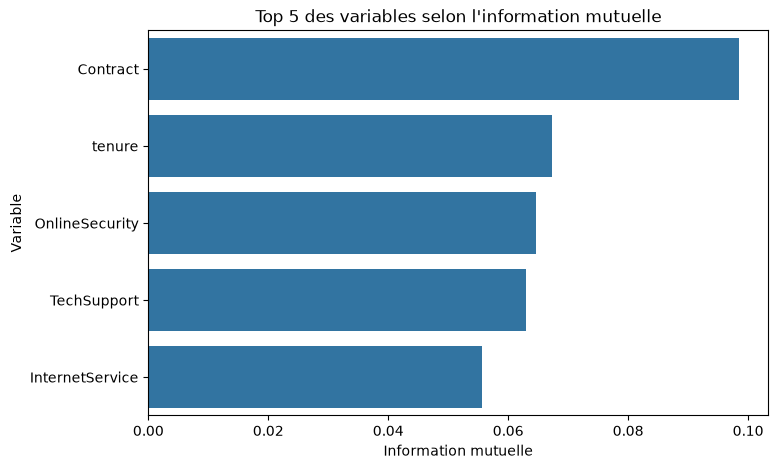

In [52]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=top5_mi,
    x="Information_mutuelle(score)",
    y="Feature"
)

plt.title("Top 5 des variables selon l'information mutuelle")
plt.xlabel("Information mutuelle")
plt.ylabel("Variable")

plt.show()


## 6. Vérification des hypothèses

À partir des résultats obtenus lors de l'analyse exploratoire, nous formulons
plusieurs hypothèses concernant les caractéristiques associées au churn.

L'objectif est de vérifier graphiquement si certaines catégories ou certains
profils de clients présentent effectivement un risque de résiliation plus élevé.

Les hypothèses retenues sont :

- **H1 — Contrat :** les clients avec un contrat mensuel (`Month-to-month`)
  présentent un taux de churn plus élevé que les clients engagés sur un ou
  deux ans.

- **H2 — Ancienneté :** les clients ayant une faible ancienneté (`tenure`)
  sont davantage représentés parmi les clients qui résilient.

- **H3 — Support technique :** les clients ne disposant pas de support
  technique (`TechSupport`) présentent un taux de churn plus élevé que ceux
  disposant de ce service.

- **H4 — Service Internet :** le taux de churn varie selon le type de service
  Internet et est particulièrement élevé chez les clients utilisant la fibre
  optique (`Fiber optic`).

Ces hypothèses décrivent des associations à vérifier dans les données et ne
constituent pas des relations causales.

### 6.1. H1 — Type de contrat et churn

**Hypothèse H1 :** les clients disposant d'un contrat mensuel présentent un
taux de churn plus élevé que les clients ayant un contrat d'un ou deux ans.

Nous comparons le taux de churn entre les trois types de contrat.

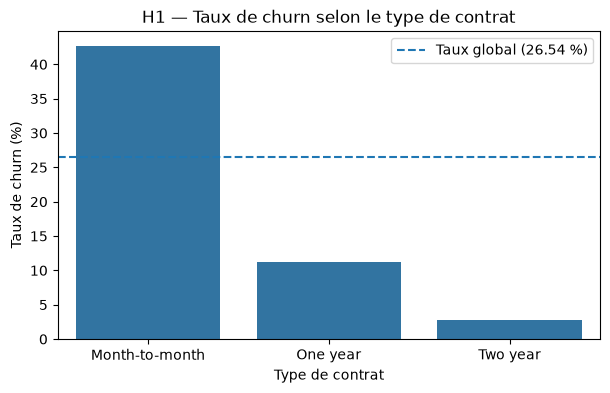

In [53]:
contract_rate = (
    df.groupby("Contract")["Churn_num"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 4))

sns.barplot(
    x=contract_rate.index,
    y=contract_rate.values
)

plt.axhline(
    churn_global,
    linestyle="--",
    label=f"Taux global ({churn_global:.2f} %)"
)

plt.title("H1 — Taux de churn selon le type de contrat")
plt.xlabel("Type de contrat")
plt.ylabel("Taux de churn (%)")
plt.legend()

plt.show()

#### Conclusion H1

L'hypothèse **H1 est confirmée dans les données**.

Les clients disposant d'un contrat `Month-to-month` présentent un taux de
churn de **42,71 %**, largement supérieur aux clients ayant un contrat
`One year` (**11,27 %**) ou `Two year` (**2,83 %**).

La durée d'engagement apparaît donc fortement associée au churn : les clients
sans engagement de longue durée sont davantage représentés parmi les clients
qui résilient.

**Chiffres obtenus grace a la question 4.3 et 5.4**

### 6.2. H2 — Ancienneté et churn

**Hypothèse H2 :** les clients ayant une faible ancienneté sont davantage
représentés parmi les clients ayant résilié.

Nous comparons la distribution de `tenure` selon le statut de churn.

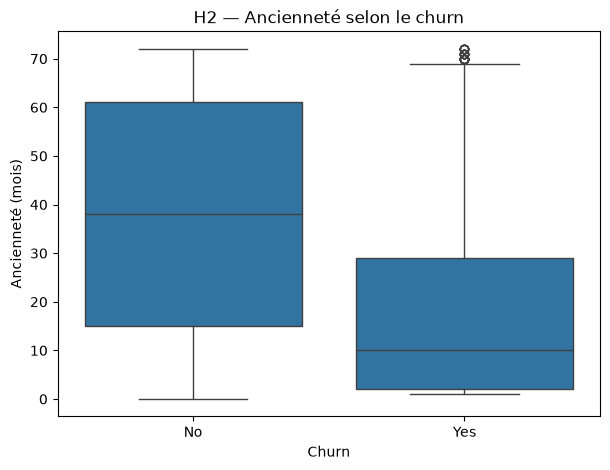

In [54]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("H2 — Ancienneté selon le churn")
plt.xlabel("Churn")
plt.ylabel("Ancienneté (mois)")

plt.show()

#### Conclusion H2

L'hypothèse **H2 est confirmée dans les données**.

La médiane d'ancienneté est de seulement **10 mois** chez les clients ayant
churné, contre **38 mois** chez les clients n'ayant pas churné.

Les clients ayant résilié présentent donc globalement une ancienneté beaucoup
plus faible. `tenure` apparaît également en deuxième position du classement
par information mutuelle, ce qui renforce son intérêt pour la suite du projet.

**Chiffres obtenus a la partie 5.5**

### 6.3. H3 — Support technique et churn

**Hypothèse H3 :** parmi les clients disposant d'un service Internet, ceux
qui ne disposent pas de support technique présentent un taux de churn plus
élevé que ceux qui disposent de ce service.

La modalité `No internet service` est distinguée, car elle correspond à des
clients ne disposant pas de service Internet et ne doit pas être interprétée
comme un simple refus du support technique.

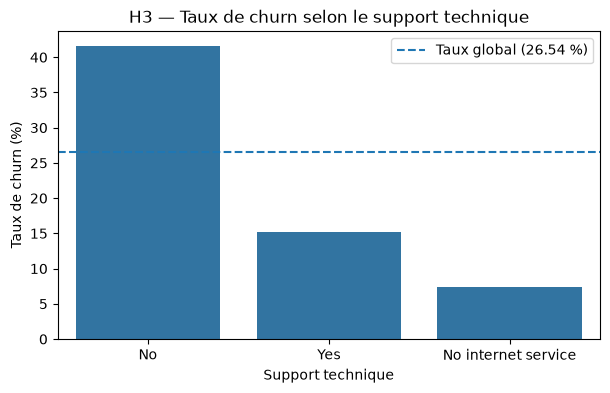

In [55]:
techsupport_rate = (
    df.groupby("TechSupport")["Churn_num"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 4))

sns.barplot(
    x=techsupport_rate.index,
    y=techsupport_rate.values
)

plt.axhline(
    churn_global,
    linestyle="--",
    label=f"Taux global ({churn_global:.2f} %)"
)

plt.title("H3 — Taux de churn selon le support technique")
plt.xlabel("Support technique")
plt.ylabel("Taux de churn (%)")
plt.legend()

plt.show()

#### Conclusion H3

L'hypothèse **H3 est confirmée dans les données**.

Parmi les clients concernés par un service Internet, ceux ne disposant pas
de `TechSupport` présentent un taux de churn de **41,64 %**, contre seulement
**15,17 %** pour ceux disposant d'un support technique.

La présence d'un support technique est donc associée à un taux de churn plus
faible.

La modalité `No internet service` présente un taux de **7,40 %**, mais
correspond à un profil différent puisqu'il s'agit de clients sans service
Internet.

**Chiffres obtenus a la partie 4.3**

### 6.4. H4 — Service Internet et churn

**Hypothèse H4 :** le taux de churn varie selon le type de service Internet
et les clients utilisant la fibre optique présentent le taux de churn le
plus élevé.

Nous comparons les taux de churn des clients utilisant la fibre optique,
DSL ou aucun service Internet.

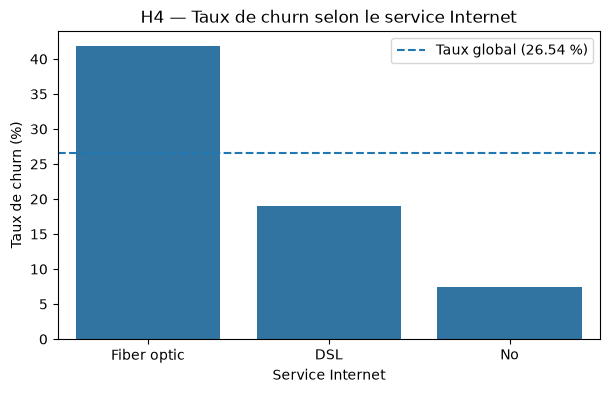

In [57]:
internet_rate = (
    df.groupby("InternetService")["Churn_num"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 4))

sns.barplot(
    x=internet_rate.index,
    y=internet_rate.values
)

plt.axhline(
    churn_global,
    linestyle="--",
    label=f"Taux global ({churn_global:.2f} %)"
)

plt.title("H4 — Taux de churn selon le service Internet")
plt.xlabel("Service Internet")
plt.ylabel("Taux de churn (%)")
plt.legend()

plt.show()

#### Conclusion H4

L'hypothèse **H4 est confirmée dans les données**.

Les clients utilisant la fibre optique présentent un taux de churn de
**41,89 %**, nettement supérieur aux clients utilisant DSL (**18,96 %**) et
aux clients sans service Internet (**7,40 %**).

Le type de service Internet semble donc associé au churn, avec un risque
particulièrement élevé observé chez les clients utilisant la fibre optique.

Cette association ne permet toutefois pas de conclure que la fibre optique
est directement responsable du churn. D'autres caractéristiques de ces
clients peuvent expliquer une partie de cette différence.

**Chiffres obtenus a la partie 4.3**


### 6.5. Synthèse des hypothèses

Les quatre hypothèses formulées sont confirmées par l'analyse exploratoire
du dataset :

- **H1 — Contrat : confirmée.** Les contrats mensuels présentent un taux de
  churn nettement supérieur aux contrats d'un ou deux ans.

- **H2 — Ancienneté : confirmée.** Les clients ayant churné présentent
  globalement une ancienneté beaucoup plus faible.

- **H3 — Support technique : confirmée.** Parmi les clients disposant
  d'Internet, l'absence de support technique est associée à un taux de churn
  plus élevé.

- **H4 — Service Internet : confirmée.** Les clients utilisant la fibre
  optique présentent le taux de churn le plus élevé selon le type de service
  Internet.

Ces résultats mettent notamment en évidence l'importance de l'engagement,
de l'ancienneté et des services souscrits dans la caractérisation des clients
à risque.

Ces observations pourront guider le feature engineering lors de la Mission 2,
sans pour autant être interprétées comme des relations causales.

# Conclusion — Mission 1 : Analyse exploratoire des données

Cette analyse exploratoire a permis d'étudier les **7 043 clients** et les
**21 variables** du dataset Telco Customer Churn afin d'identifier les
principales caractéristiques associées à la résiliation.

## Qualité des données

Le dataset ne contient aucun doublon et les **7 043 `customerID` sont uniques**.
Aucune variable quasi-constante n'a été détectée avec un seuil de 95 %.

Aucune valeur manquante n'est détectée directement par `isna()`. Cependant,
l'analyse de `TotalCharges` révèle **11 valeurs non convertibles**, correspondant
à des clients ayant une ancienneté (`tenure`) égale à 0.

Une forte corrélation positive d'environ **0,83** a également été observée entre
`tenure` et `TotalCharges_num`, ce qui est cohérent puisque les charges totales
accumulées augmentent généralement avec l'ancienneté.

Aucune fuite de données évidente n'a été identifiée parmi les variables
explicatives. `customerID` sera néanmoins exclue de la modélisation puisqu'il
s'agit d'un identifiant unique.

## Analyse du churn

Le taux global de churn est de **26,54 %**, ce qui montre un déséquilibre modéré
entre les clients ayant résilié et ceux étant restés.

L'analyse bivariée montre que plusieurs caractéristiques sont fortement
associées au churn, notamment le type de contrat, l'ancienneté, le service
Internet, le support technique et certains services souscrits.

Le classement par information mutuelle identifie les cinq variables les plus
discriminantes :

1. `Contract` : **0,0985**
2. `tenure` : **0,0673**
3. `OnlineSecurity` : **0,0647**
4. `TechSupport` : **0,0630**
5. `InternetService` : **0,0556**

## Trois insights majeurs

**1. Le type de contrat est fortement associé au churn.**

Les clients en contrat `Month-to-month` présentent **42,71 %** de churn,
contre **11,27 %** pour un contrat d'un an et seulement **2,83 %** pour un
contrat de deux ans. `Contract` obtient également le score d'information
mutuelle le plus élevé.

**2. Les clients ayant churné ont généralement une ancienneté plus faible.**

La médiane de `tenure` est de **10 mois** chez les clients ayant résilié,
contre **38 mois** chez ceux n'ayant pas résilié. `tenure` est également la
deuxième variable du classement par information mutuelle.

**3. Les services Internet et d'assistance sont fortement associés au churn.**

Les clients utilisant la fibre optique présentent **41,89 %** de churn.
Par ailleurs, les clients ne disposant pas de support technique présentent
**41,64 %** de churn, contre **15,17 %** pour ceux disposant de ce service.
`InternetService` et `TechSupport` figurent toutes deux parmi les cinq
variables les plus discriminantes.

## Hypothèses retenues

Les quatre hypothèses étudiées sont confirmées par les observations du dataset :

- les clients en contrat mensuel présentent davantage de churn ;
- les clients ayant une faible ancienneté sont davantage représentés parmi
  les clients ayant résilié ;
- parmi les clients disposant d'Internet, l'absence de support technique est
  associée à davantage de churn ;
- les clients utilisant la fibre optique présentent un taux de churn supérieur
  aux autres catégories de service Internet.

Ces résultats constituent des associations observées dans les données et ne
doivent pas être interprétés comme des relations causales.

Ils serviront de base à la préparation des données et au feature engineering
de la Mission 2.